In [1]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

In [2]:
# LOAD DATA

train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("val.csv")
test_df = pd.read_csv("test.csv")

# TEXT + LABEL

X_train = train_df["text"].astype(str)
y_train = train_df["label_id"]

X_val = val_df["text"].astype(str)
y_val = val_df["label_id"]

X_test = test_df["text"].astype(str)
y_test = test_df["label_id"]

In [3]:
# TOKENIZE

MAX_WORDS = 20000
MAX_LEN = 300

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

train_seq = tokenizer.texts_to_sequences(X_train)
val_seq = tokenizer.texts_to_sequences(X_val)
test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(
    train_seq,
    maxlen=MAX_LEN,
    padding='post'
)

X_val_pad = pad_sequences(
    val_seq,
    maxlen=MAX_LEN,
    padding='post'
)

X_test_pad = pad_sequences(
    test_seq,
    maxlen=MAX_LEN,
    padding='post'
)

In [4]:
# BUILD MODEL

model = Sequential([

    Embedding(
        MAX_WORDS,
        128,
        input_length=MAX_LEN
    ),

    Bidirectional(
        LSTM(64)
    ),

    Dropout(0.5),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
# CALLBACKS

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [6]:
# TRAIN

history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[
        early_stop,
        checkpoint
    ]
)

Epoch 1/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.8346 - loss: 0.3819
Epoch 1: val_accuracy improved from None to 0.92966, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
326/326 ━━━━━━━━━━━━━━━━━━━━ 110s 326ms/step - accuracy: 0.8942 - loss: 0.2697 - val_accuracy: 0.9297 - val_loss: 0.1861
Epoch 2/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.9592 - loss: 0.1186
Epoch 2: val_accuracy improved from 0.92966 to 0.94131, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
326/326 ━━━━━━━━━━━━━━━━━━━━ 105s 323ms/step - accuracy: 0.9600 - loss: 0.1153 - val_accuracy: 0.9413 - val_loss: 0.1632
Epoch 3/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.9823 - loss: 0.0581
Epoch 3: val_accuracy improved from 0.94131 to 0.94176, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
326/326 ━━━━━━━━━━━━━━━━━━━━ 133s 295ms/step - accuracy: 0.9815 - loss: 0.

In [7]:
# EVALUATE

# xác suất dự đoán
y_pred_prob = model.predict(X_test_pad)

# chuyển về nhãn 0/1
y_pred = (y_pred_prob > 0.5).astype(int)

# flatten để tránh shape (n,1)
y_pred_prob = y_pred_prob.ravel()
y_pred = y_pred.ravel()

# tính các metric
acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# in kết quả
print("\n===== TEST METRICS =====")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred, digits=4))

70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step

===== TEST METRICS =====
Accuracy : 0.9315
Precision: 0.9227
Recall   : 0.8793
F1-score : 0.9005
ROC-AUC  : 0.9767

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0     0.9359    0.9599    0.9478      1446
           1     0.9227    0.8793    0.9005       787

    accuracy                         0.9315      2233
   macro avg     0.9293    0.9196    0.9241      2233
weighted avg     0.9313    0.9315    0.9311      2233



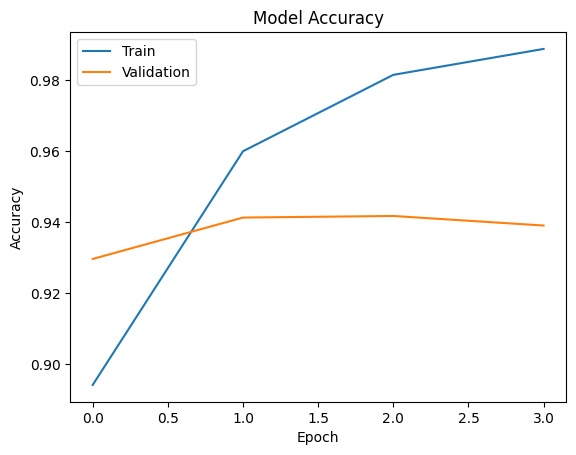

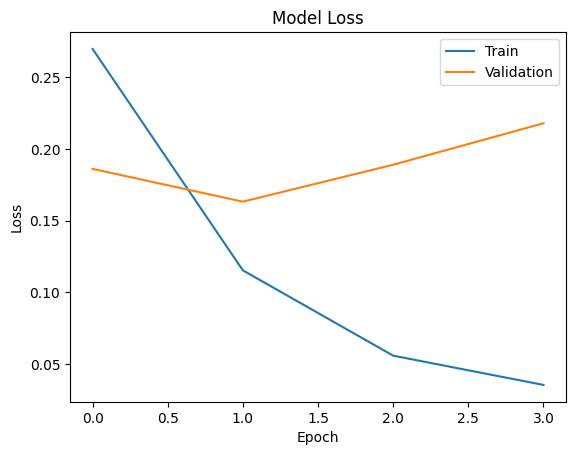

In [8]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

Biểu đồ độ chính xác và hàm mất mát cho thấy mô hình BiLSTM học tốt trên tập huấn luyện khi accuracy tăng đều từ khoảng 89.5% lên gần 99%, đồng thời loss giảm mạnh từ khoảng 0.27 xuống còn gần 0.03 qua các epoch.

Đối với tập validation, accuracy chỉ tăng nhẹ và ổn định quanh mức 94%, trong khi loss giảm ở giai đoạn đầu nhưng tăng dần từ các epoch sau.

Điều này cho thấy mô hình bắt đầu xuất hiện dấu hiệu overfitting từ khoảng epoch thứ 2, tuy nhiên mức chênh lệch chưa lớn và mô hình vẫn duy trì khả năng tổng quát hóa tương đối tốt. Vì vậy, kỹ thuật EarlyStopping được sử dụng nhằm dừng huấn luyện tại thời điểm phù hợp và khôi phục lại trọng số tốt nhất của mô hình.

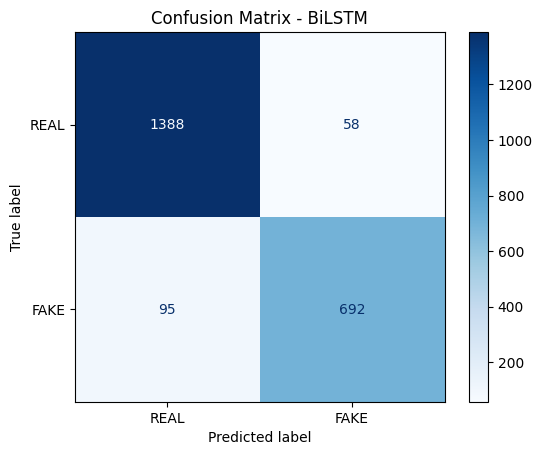

In [9]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["REAL", "FAKE"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - BiLSTM")
plt.show()

In [10]:
# lưu model
model.save("bilstm_fake_news.h5")

In [11]:
# test bài báo mới
sample_text = """
WHO xác nhận vaccine mới có hiệu quả chống biến thể mới của COVID-19.
"""

seq = tokenizer.texts_to_sequences([sample_text])

pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post')

pred = model.predict(pad)

print(pred)

if pred > 0.5:
    print("FAKE NEWS")
else:
    print("REAL NEWS")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
[[0.07058275]]
REAL NEWS
